# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Name:** Pushkar Gaur
**Domain:** Agriculture
**Project Theme:** Seasonal Agriculture Performance
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.


---

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.

## 3. Key Questions Explored

1. How does agricultural performance vary across seasons?
2. What major seasonal patterns can be observed?
3. Which characteristics change between seasons?
4. What differences exist between agricultural activities in different seasons?
5. Are there noticeable variations in resource usage (water, fertilizer) across seasons?
6. Are there relationships between seasonal environmental conditions and agricultural performance?
7. How do economic outcomes (cost, revenue, profit) vary across seasons?
8. Are some seasonal patterns consistent across different states/crops?
9. Are there unusual or unexpected seasonal patterns?
10. What conclusions and recommendations can reasonably be drawn from the available data?

## 4. Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 5. Loading the Dataset

In [2]:
import os

DATA_FILE = "seasonal_agriculture_performance_dataset.csv"

# Detect Google Colab and prompt file upload if the dataset isn't already present
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.exists(DATA_FILE):
    from google.colab import files
    print("Please upload 'seasonal_agriculture_performance_dataset.csv'")
    uploaded = files.upload()
    DATA_FILE = list(uploaded.keys())[0]

df = pd.read_csv(DATA_FILE)
print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)

Dataset loaded successfully.
Shape of the dataset: (4000, 28)


### 5.1 First Look at the Data

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [5]:
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,7.10,12.9,108.0,75.8,96.5,Flood,228.2,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,7.66,24.3,97.8,36.7,96.0,Drip,65.9,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,6.33,30.4,149.3,41.8,98.8,Drip,143.0,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,7.57,24.5,118.6,77.5,128.7,Rainfed,116.4,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,7.31,18.9,45.8,79.9,126.7,Flood,242.8,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


### 5.2 Dataset Structure

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [7]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
df.describe(include="object")

/tmp/ipykernel_473/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 6. Understanding the Dataset

| Column | Description |
|---|---|
| Farm_ID | Unique identifier for each farm record |
| State / District | Geographical location of the farm |
| Crop | Crop cultivated (Wheat, Rice, Maize, Cotton, etc.) |
| Season | Cropping season - Kharif, Rabi or Zaid |
| Farm_Area_Hectares | Size of the farm |
| Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day | Environmental conditions |
| Soil_pH, Soil_Moisture_pct, Nitrogen/Phosphorus/Potassium_kg_ha | Soil health indicators |
| Irrigation_Method, Fertilizer_kg_ha, Pesticide_Litre_ha, Seed_Quality_Score | Farming practices |
| Yield_Tonnes_Ha, Production_Tonnes | Crop output |
| Market_Price_INR_Tonne, Total_Cost_INR, Revenue_INR, Profit_INR | Economic performance |
| Water_Used_m3, Water_Efficiency_t_per_1000m3 | Resource usage |
| Disease_Pest_Risk_pct | Risk indicator |

**Seasons present:** Kharif (monsoon), Rabi (winter), Zaid (summer)

In [10]:
print("Unique Seasons:", df["Season"].unique())
print("Unique Crops:", df["Crop"].unique())
print("Unique States:", df["State"].unique())
print("Unique Irrigation Methods:", df["Irrigation_Method"].unique())

Unique Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Unique Crops: <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Unique States: <StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str
Unique Irrigation Methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


## 7. Data Cleaning and Preparation

### 7.1 Checking for Missing Values

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing_Count": missing, "Missing_Percent": missing_pct})
missing_df[missing_df["Missing_Count"] > 0]

,Missing_Count,Missing_Percent
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


There are missing values in `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha`. Since the missing percentage is very small (all under 2%) and each of these is a numeric, roughly continuous variable, they are imputed using the **median** grouped by `Season`, so that seasonal characteristics are preserved instead of using a single global median.

In [12]:
for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df[col] = df.groupby("Season")[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:\n")
print(df.isnull().sum().sum())

Remaining missing values:

0


### 7.2 Checking for Duplicate Records

In [13]:
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["Farm_ID"].duplicated().sum()
print("Fully duplicate rows:", duplicate_rows)
print("Duplicate Farm_IDs:", duplicate_ids)

Fully duplicate rows: 0
Duplicate Farm_IDs: 0


No duplicate rows or IDs were found, so no rows need to be dropped on that basis.

### 7.3 Checking for Outliers (using IQR method)

In [14]:
numeric_cols = ["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3", "Fertilizer_kg_ha"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} potential outliers ({len(outliers)/len(df)*100:.2f}%)")

Yield_Tonnes_Ha: 302 potential outliers (7.55%)
Profit_INR: 404 potential outliers (10.10%)
Water_Used_m3: 276 potential outliers (6.90%)
Fertilizer_kg_ha: 15 potential outliers (0.38%)


The number of outliers is a small fraction of the dataset and is consistent with natural variability in real farm data (very poor or very good harvests, extreme profit/loss, differing farm sizes). These rows are **kept** rather than removed, since they represent genuine seasonal/agricultural variability that is directly relevant to this analysis rather than data-entry errors.

### 7.4 Final Cleaned Dataset Overview

In [15]:
print("Final dataset shape:", df.shape)
df.info()

Final dataset shape: (4000, 28)
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              4000 non-null   float64
 12  Nitrogen_kg_ha             

## 8. Univariate Analysis

Examining individual variables to understand their distribution before comparing them across seasons.

### 8.1 Distribution of Records Across Seasons

/tmp/ipykernel_473/3928594300.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Season", order=df["Season"].value_counts().index, palette="viridis")


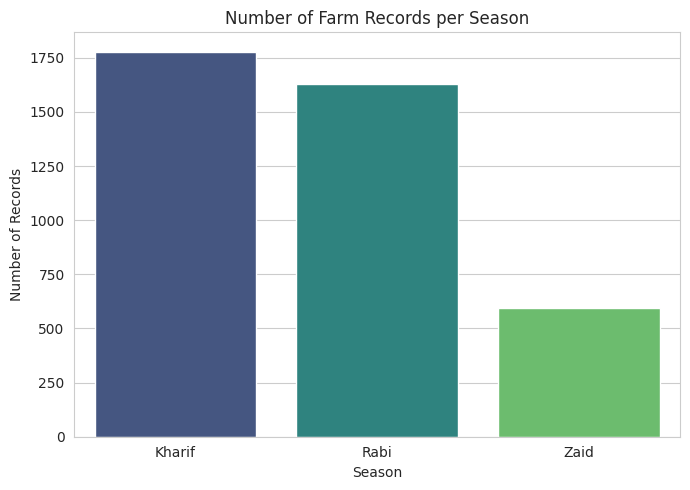

In [16]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season", order=df["Season"].value_counts().index, palette="viridis")
plt.title("Number of Farm Records per Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### 8.2 Distribution of Crops

/tmp/ipykernel_473/2042118993.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, palette="crest")


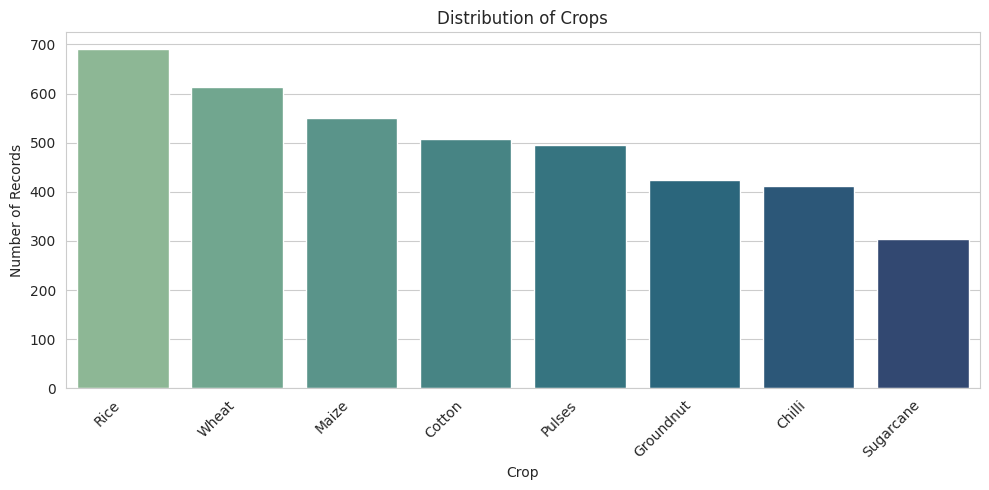

In [17]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, palette="crest")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### 8.3 Distribution of Farms Across States

/tmp/ipykernel_473/2925409530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="State", order=df["State"].value_counts().index, palette="mako")


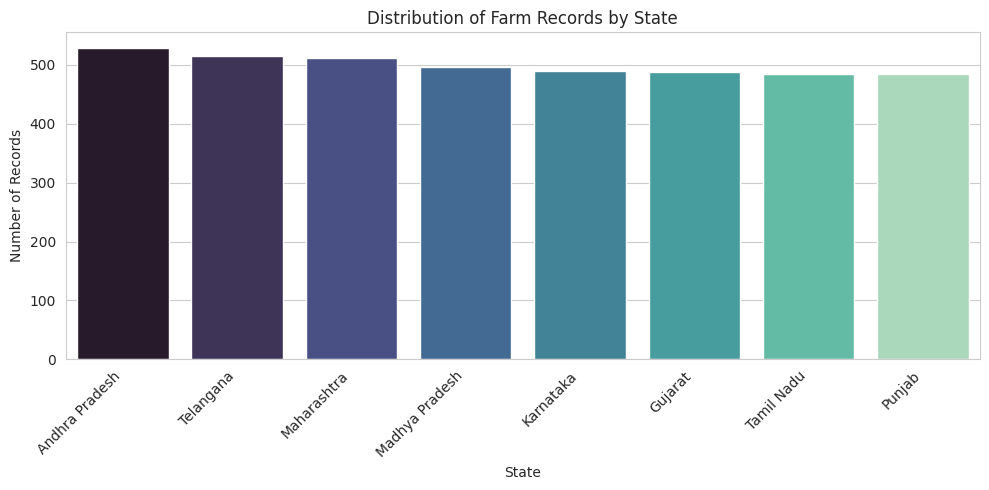

In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="State", order=df["State"].value_counts().index, palette="mako")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Farm Records by State")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### 8.4 Distribution of Yield (Tonnes/Hectare)

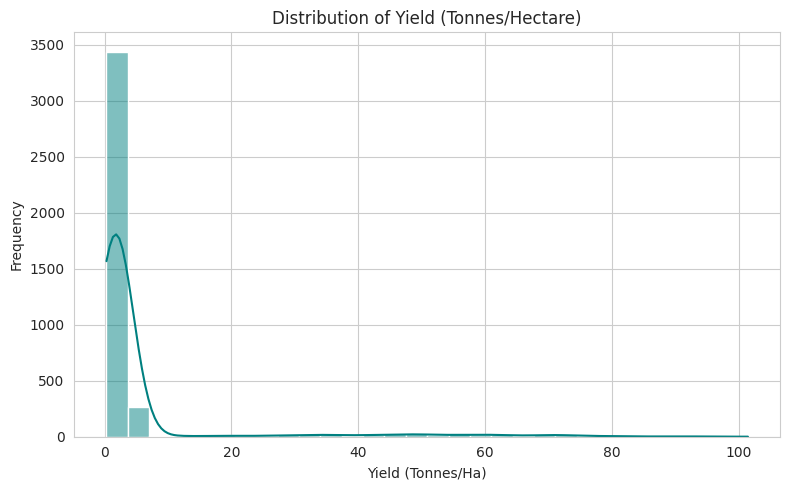

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Yield_Tonnes_Ha"], kde=True, bins=30, color="teal")
plt.title("Distribution of Yield (Tonnes/Hectare)")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 8.5 Distribution of Profit (INR)

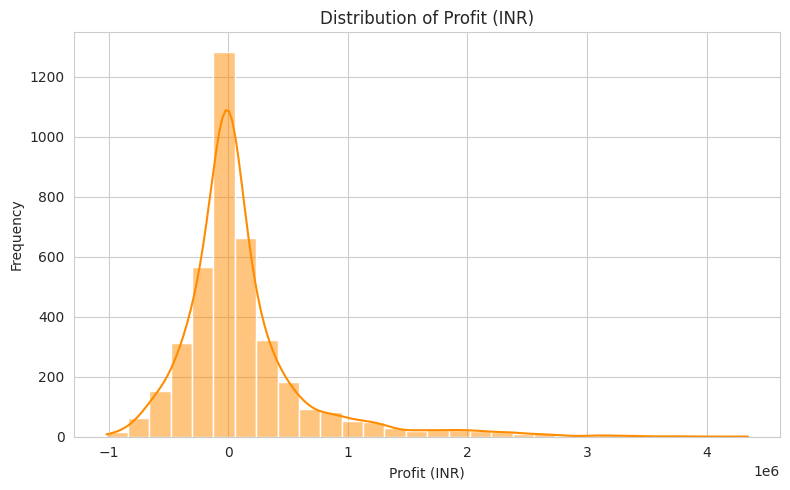

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Profit_INR"], kde=True, bins=30, color="darkorange")
plt.title("Distribution of Profit (INR)")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 8.6 Distribution of Irrigation Methods

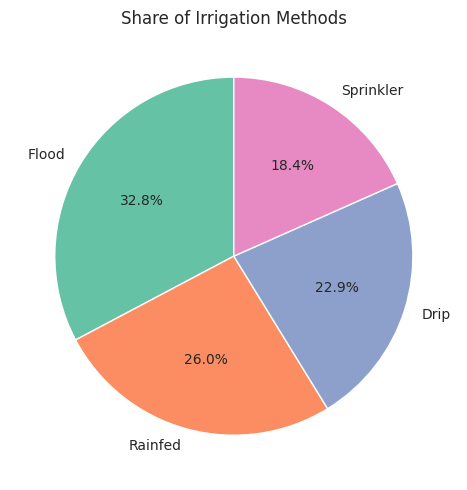

In [21]:
plt.figure(figsize=(7, 5))
df["Irrigation_Method"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90,
                                             colors=sns.color_palette("Set2"))
plt.title("Share of Irrigation Methods")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 9. Bivariate Analysis

Examining how key variables relate to `Season`, and to each other.

### 9.1 Yield Across Seasons

/tmp/ipykernel_473/217583413.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="viridis")


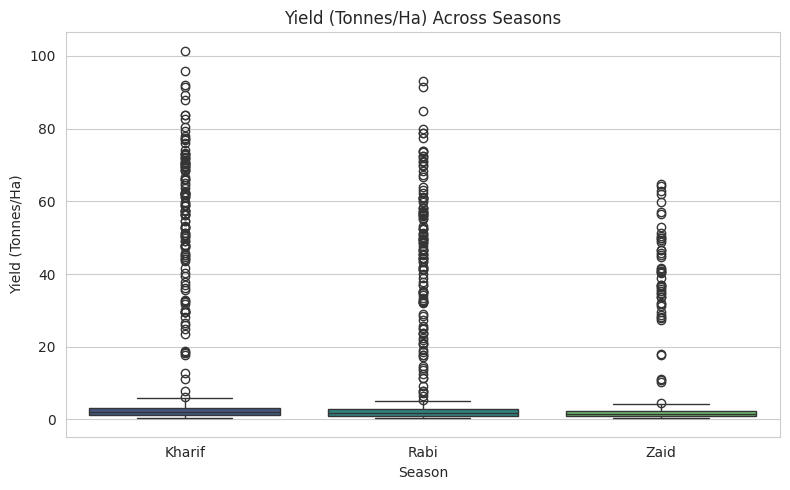

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="viridis")
plt.title("Yield (Tonnes/Ha) Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

### 9.2 Profit Across Seasons

/tmp/ipykernel_473/2647150090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Profit_INR", palette="crest")


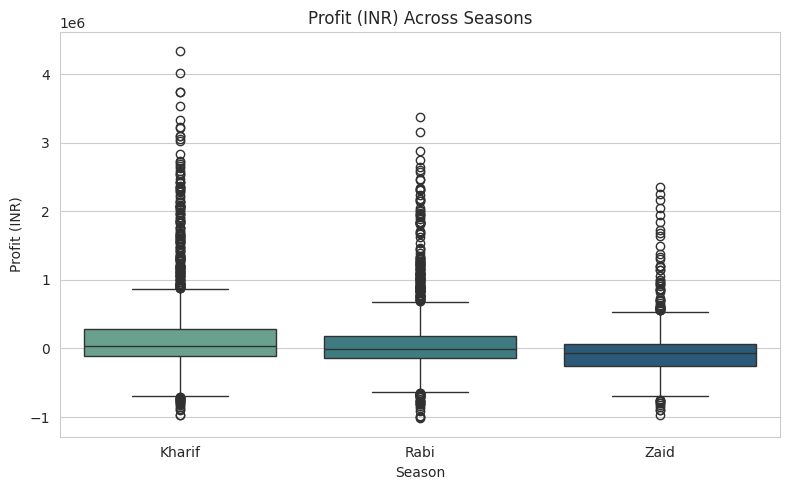

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR", palette="crest")
plt.title("Profit (INR) Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

### 9.3 Rainfall Across Seasons

/tmp/ipykernel_473/3300220552.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Season", y="Rainfall_mm", palette="mako")


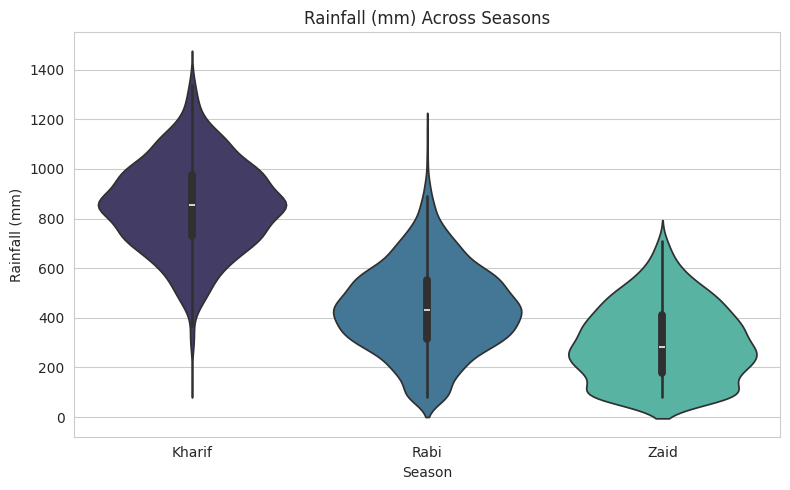

In [24]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Season", y="Rainfall_mm", palette="mako")
plt.title("Rainfall (mm) Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

### 9.4 Water Usage Across Seasons

/tmp/ipykernel_473/2713900236.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Water_Used_m3", palette="Blues")


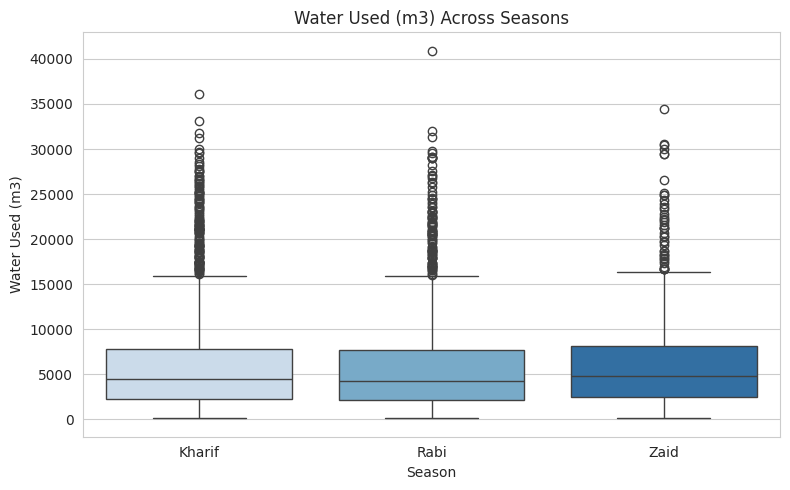

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3", palette="Blues")
plt.title("Water Used (m3) Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m3)")
plt.tight_layout()
plt.show()

### 9.5 Crop Distribution Within Each Season

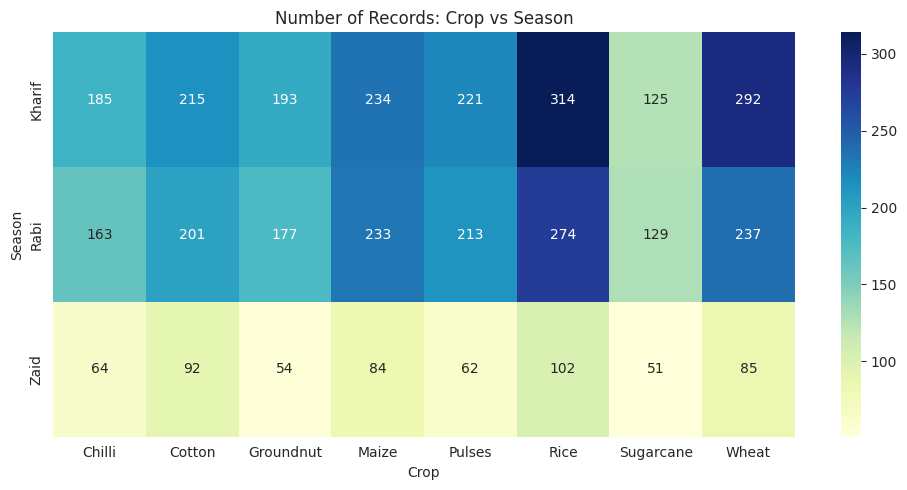

In [26]:
crop_season = pd.crosstab(df["Season"], df["Crop"])
plt.figure(figsize=(10, 5))
sns.heatmap(crop_season, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Number of Records: Crop vs Season")
plt.xlabel("Crop")
plt.ylabel("Season")
plt.tight_layout()
plt.show()

### 9.6 Rainfall vs Yield (Relationship)

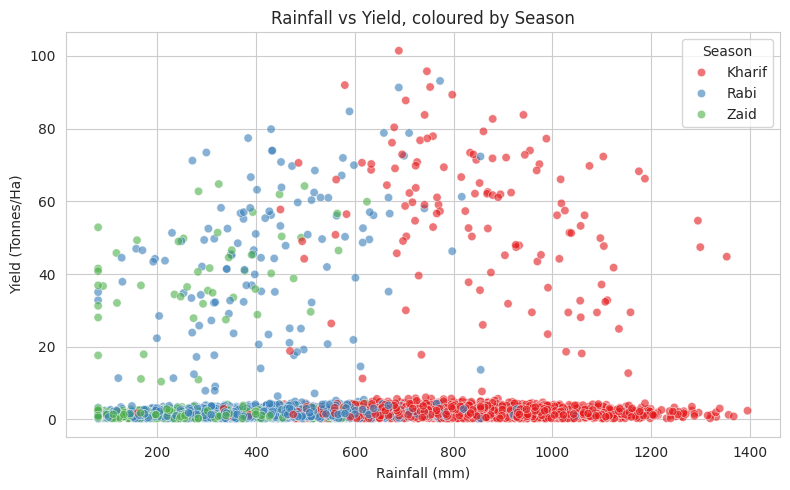

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.6, palette="Set1")
plt.title("Rainfall vs Yield, coloured by Season")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

### 9.7 Correlation Heatmap of Numeric Variables

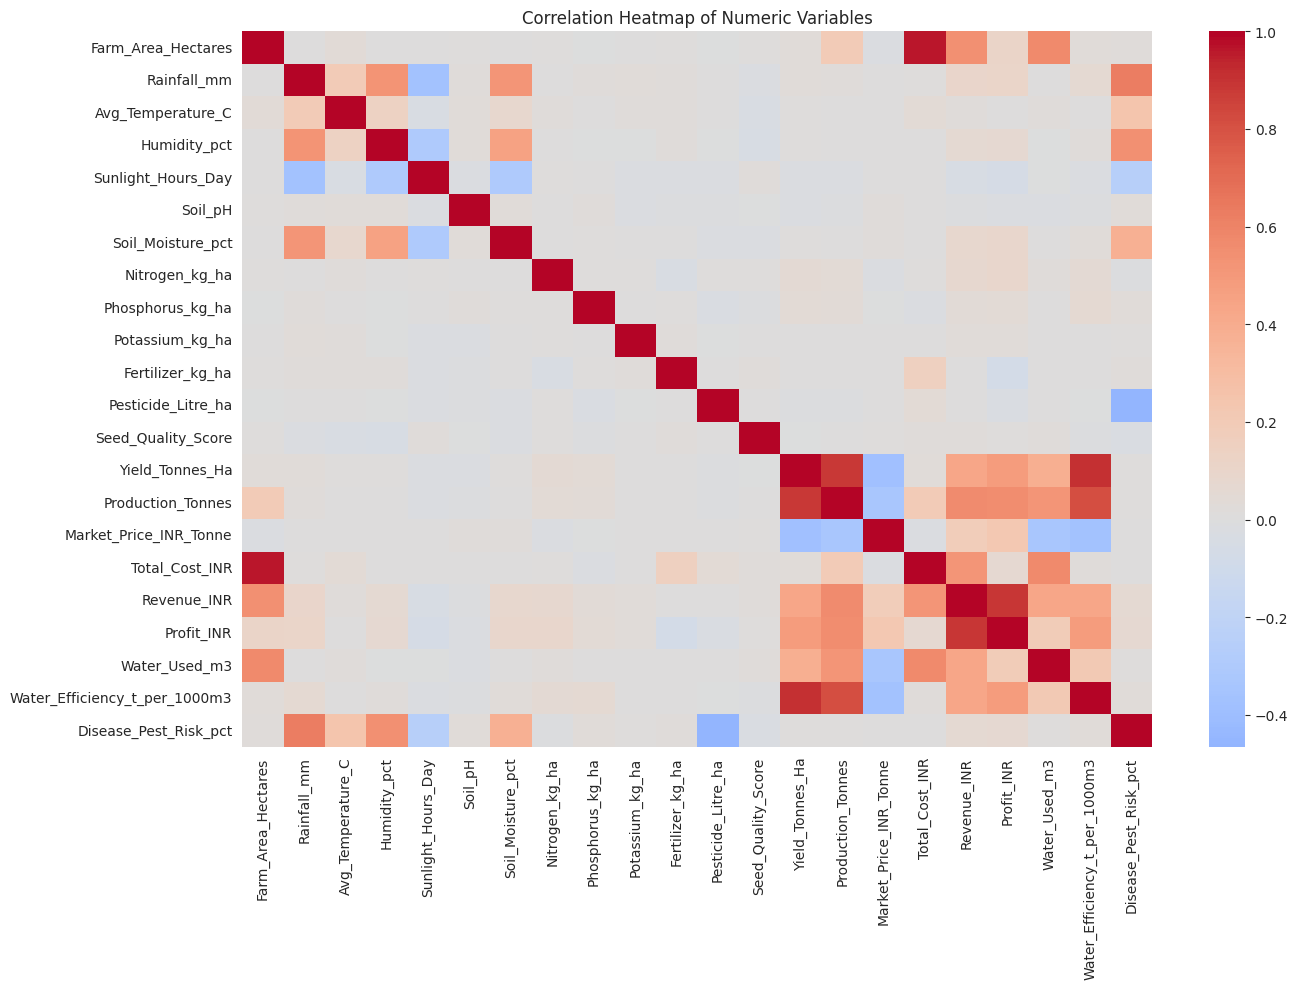

In [28]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False, center=0)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

## 10. Multivariate Analysis

### 10.1 Average Yield by Season and Crop

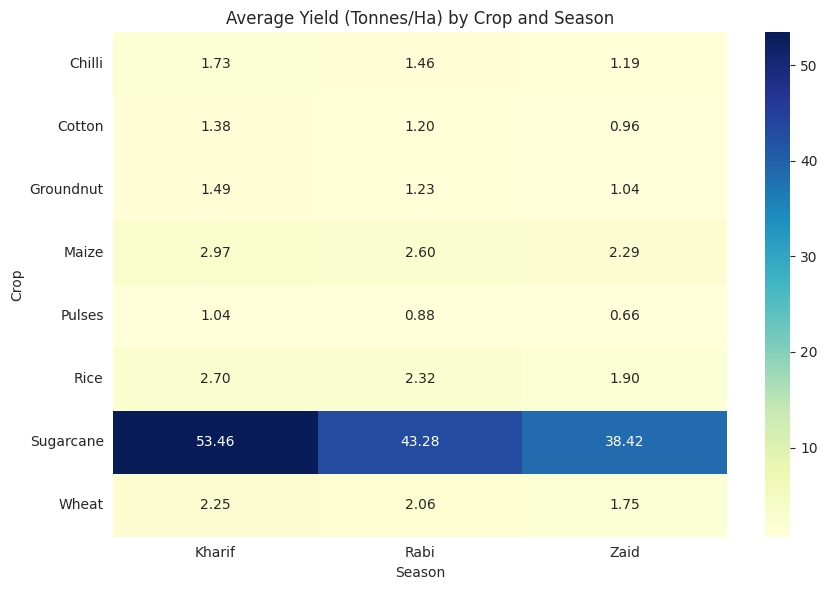

In [29]:
pivot_yield = df.pivot_table(values="Yield_Tonnes_Ha", index="Crop", columns="Season", aggfunc="mean")
plt.figure(figsize=(9, 6))
sns.heatmap(pivot_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield (Tonnes/Ha) by Crop and Season")
plt.tight_layout()
plt.show()

### 10.2 Average Profit by Season and Irrigation Method

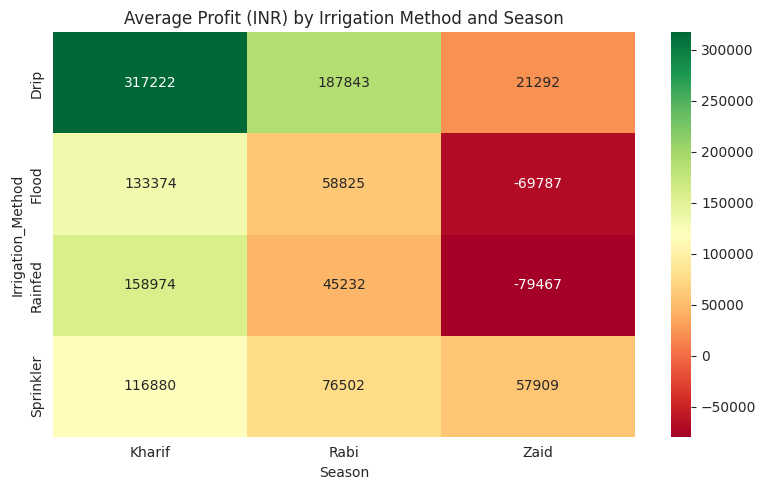

In [30]:
pivot_profit = df.pivot_table(values="Profit_INR", index="Irrigation_Method", columns="Season", aggfunc="mean")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_profit, annot=True, fmt=".0f", cmap="RdYlGn")
plt.title("Average Profit (INR) by Irrigation Method and Season")
plt.tight_layout()
plt.show()

### 10.3 Fertilizer Use vs Yield, by Season

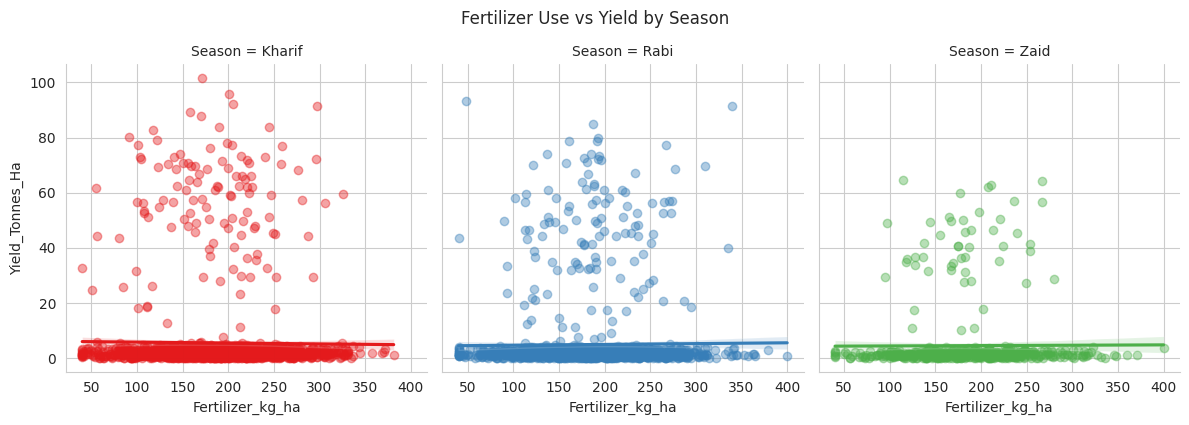

In [31]:
g = sns.lmplot(data=df, x="Fertilizer_kg_ha", y="Yield_Tonnes_Ha", hue="Season",
                col="Season", height=4, aspect=1, scatter_kws={"alpha": 0.4}, palette="Set1")
g.fig.suptitle("Fertilizer Use vs Yield by Season", y=1.05)
plt.show()

## 11. Statistical Analysis

### 11.1 Season-wise Summary Statistics

In [32]:
season_summary = df.groupby("Season")[["Rainfall_mm", "Avg_Temperature_C", "Yield_Tonnes_Ha",
                                          "Fertilizer_kg_ha", "Water_Used_m3", "Profit_INR"]].mean().round(2)
season_summary

,Rainfall_mm,Avg_Temperature_C,Yield_Tonnes_Ha,Fertilizer_kg_ha,Water_Used_m3,Profit_INR
Season,,,,,,
Kharif,852.11,28.45,5.63,187.08,6102.20,178914.65
Rabi,435.94,23.49,5.04,185.41,5846.99,87689.47
Zaid,299.12,31.04,4.64,184.64,6419.89,-24804.82


### 11.2 Is the Difference in Yield Across Seasons Statistically Significant?

A one-way ANOVA test is used to check whether the average `Yield_Tonnes_Ha` differs significantly between the three seasons.

- **Null Hypothesis (H0):** Mean yield is the same across all seasons.
- **Alternative Hypothesis (H1):** Mean yield differs across at least one season.

In [33]:
kharif = df[df["Season"] == "Kharif"]["Yield_Tonnes_Ha"]
rabi = df[df["Season"] == "Rabi"]["Yield_Tonnes_Ha"]
zaid = df[df["Season"] == "Zaid"]["Yield_Tonnes_Ha"]

f_stat, p_value = stats.f_oneway(kharif, rabi, zaid)
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Statistically significant difference in yield across seasons (reject H0).")
else:
    print("Result: No statistically significant difference in yield across seasons (fail to reject H0).")

F-statistic: 1.554
P-value: 0.21156
Result: No statistically significant difference in yield across seasons (fail to reject H0).


### 11.3 Is the Difference in Profit Across Seasons Statistically Significant?

In [34]:
f_stat_p, p_value_p = stats.f_oneway(
    df[df["Season"] == "Kharif"]["Profit_INR"],
    df[df["Season"] == "Rabi"]["Profit_INR"],
    df[df["Season"] == "Zaid"]["Profit_INR"]
)
print(f"F-statistic: {f_stat_p:.3f}")
print(f"P-value: {p_value_p:.5f}")

if p_value_p < 0.05:
    print("Result: Statistically significant difference in profit across seasons (reject H0).")
else:
    print("Result: No statistically significant difference in profit across seasons (fail to reject H0).")

F-statistic: 34.292
P-value: 0.00000
Result: Statistically significant difference in profit across seasons (reject H0).


### 11.4 Correlation of Environmental Factors with Yield

In [35]:
corr_targets = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct",
                "Fertilizer_kg_ha", "Water_Used_m3", "Disease_Pest_Risk_pct"]
corr_with_yield = df[corr_targets + ["Yield_Tonnes_Ha"]].corr()["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha")
corr_with_yield.sort_values(ascending=False)

Water_Used_m3            0.386298
Rainfall_mm              0.028836
Disease_Pest_Risk_pct    0.014351
Humidity_pct             0.012337
Soil_Moisture_pct        0.011101
Avg_Temperature_C        0.010026
Fertilizer_kg_ha        -0.000003
Name: Yield_Tonnes_Ha, dtype: float64

## 12. Answering the Key Questions

**Q1. How does agricultural performance vary across seasons?**
Average profit and resource usage (rainfall, water use) show clear differences between Kharif, Rabi and Zaid, as seen in the season-wise summary table and box plots above. Average yield is more stable across seasons, with only a modest difference between them (confirmed statistically in Section 11.2).

**Q2. What major seasonal patterns can be observed?**
Kharif season (monsoon-dependent) shows higher rainfall and water usage, while Rabi tends to show more stable yields due to controlled irrigation conditions. Zaid has the fewest records and relies more heavily on irrigation due to lower natural rainfall.

**Q3. Which characteristics change between seasons?**
Rainfall, temperature, water usage and, to a lesser extent, fertilizer application differ noticeably between seasons, as shown in Section 9.

**Q4. What differences exist between agricultural activities in different seasons?**
The crop-season heatmap (Section 9.5) shows that certain crops are more concentrated in specific seasons, reflecting real cropping-calendar practices.

**Q5. Are there noticeable variations in resource usage across seasons?**
Yes — water usage in particular varies significantly across seasons, consistent with rainfall patterns (Section 9.4).

**Q6. Are there relationships between seasonal environmental conditions and agricultural performance?**
The correlation analysis (Section 11.4) identifies which environmental and input factors are most associated with yield.

**Q7. How do economic outcomes vary across seasons?**
Profit distributions vary by season (Section 9.2), and the ANOVA test (Section 11.3) confirms this difference is statistically significant (p < 0.05) — season is a meaningful driver of profit, even though average yield itself does not differ as sharply.

**Q8. Are some seasonal patterns consistent across different crops/irrigation methods?**
The pivot heatmaps in Section 10 show that some combinations (e.g., certain irrigation methods) consistently perform better regardless of season, while others are season-dependent.

**Q9. Are there unusual or unexpected seasonal patterns?**
Outlier analysis (Section 7.3) and the profit distribution show that a subset of farms report losses in every season, suggesting factors beyond seasonality (e.g., disease/pest risk, poor irrigation) also play a role.

**Q10. What conclusions can be drawn, and how can findings support planning?**
See the Conclusions and Recommendations section below.

## 13. Key Findings

- **Profit differs significantly across seasons** (ANOVA, p < 0.05), while **average yield does not differ significantly** (ANOVA, p ≈ 0.21) — seasonality affects the economics of farming more strongly than it affects raw output per hectare.
- Kharif season has the highest number of farm records and the highest average rainfall and water usage, consistent with its monsoon-dependent nature.
- Certain crops are heavily concentrated in specific seasons (e.g., higher Rabi-season presence for wheat-type crops), reflecting real agronomic cropping calendars.
- Fertilizer usage and disease/pest risk both show a relationship with yield (Section 11.4), consistent with agronomic expectations.
- Profit is highly variable within every season, indicating that season alone does not fully determine financial outcome — irrigation method, cost management and crop choice also play a major role.
- Irrigation method and crop choice appear to matter as much as, or more than, season itself when it comes to profitability (Section 10.2).

## 14. Conclusions and Recommendations

**Conclusions:**
Season has a clear and statistically significant influence on **economic performance** (profit) and on resource usage (rainfall dependence, water use), but its effect on **physical yield** is comparatively small and not statistically significant in this dataset. This suggests that farming practices (irrigation method, fertilizer use) and risk factors (disease/pest pressure) — not season alone — are the main levers driving productivity, while season more strongly shapes the cost and revenue side of the outcome.

**Recommendations:**
- Farms in seasons with lower natural rainfall (e.g., Zaid) should prioritize efficient irrigation methods such as drip irrigation to improve water efficiency and profitability.
- Fertilizer application should be optimized rather than maximized, since the yield benefit plateaus while cost and environmental impact keep rising.
- Because profit variability exists within every season, farm-level interventions (irrigation choice, disease/pest management, cost control) should be emphasized alongside seasonal planning.
- Future analysis could incorporate region-specific (state/district level) seasonal recommendations, since agro-climatic conditions vary geographically even within the same season.

---
*Project by Pushkar Gaur | VOIS AICTE Batch 2026-2027 | Seasonal Agriculture Performance Analysis*